https://maartengr.github.io/BERTopic/index.html for topic analysis

In [1]:
import os
import re
from tqdm import tqdm
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import seaborn as sns

Ce notebook analyse les discours à l'aide de la bibliothèques spacy et ne garde que les mots significatifs, puis les rassemble dans un dictionnaire où les clés sont déterminés par année et par personnalité politique.

In [3]:
import os
import spacy
nlp = spacy.load("fr_core_news_sm")
import fr_core_news_sm
nlp = fr_core_news_sm.load()
discours={}
pol=[]
i=0
for disc in tqdm(os.walk('discours')):#sur 181
    if disc[1]!=[]:
        pol=disc[1]
        continue
    if i>=93:
        break
    i+=1
    way=disc[0]
    one={}
    for date in disc[2]:
        new={}
        year=int(date.split('.')[0][-4:])
        link=disc[0]+"\\"+date
        f=open(link,"r",encoding='utf-8')
        k=f.read().lower()
        f.close()
        #b=re.split(r'[^a-zA-Zà-ÿÀ-Ÿ]+',k)
        #K=[j for j in b if len(j)>3]
        doc=nlp(k)
        K=[token.text for token in doc if len(token.text) > 3 and not token.is_stop]
        del f,k,doc
        for word in K:
            if word in new:
                new[word]+=1
            else:
                new[word]=1
        if year in one:
            n=dict(Counter(new)+Counter(one[year]))
            one[year]=n
        else:
            one[year]=new

    discours[pol[i]]=one  

with open('reduced3.txt','a',encoding="utf-8") as convert_file:
    convert_file.write(str(discours))
del one,new

94it [42:13, 26.96s/it] 


ANALYSE TEMPORELLE DE LA DISTRIBUTION DES MOTS

In [147]:
import ast
with open('reduced2.txt',encoding='utf-8') as f:
    data=f.read()
discours=ast.literal_eval(data)
f.close()

In [22]:
discours.keys()

dict_keys(['Jean-Claude Sandrier', 'Jean-François Lamour', 'Jean-Jack Queyranne', 'Jean-Jacques Urvoas', 'Jean-Louis Borloo', 'Jean-Louis Thiériot', 'Jean-Marc Ayrault', 'Jean-Marie Le Guen', 'Jean-Noël Barrot', 'Joël Giraud', 'Jérôme Cahuzac', 'Kader Arif', 'Laurent Fabius', 'Laurent Hénart', 'Laurent Marcangeli', 'Laurent Pietraszewski', 'Laurent Saint-Martin', 'Laurent Wauquiez', 'Luc Chatel', 'Manuel Valls', 'Marc Ferracci', 'Marc Fesneau', 'Marc Laffineur', 'Marc-Philippe Daubresse', 'Marie Guévenoux', 'Marie Lebec', 'Marie-Anne Montchamp', 'Marie-Arlette Carlotti', 'Marie-George Buffet', 'Marie-Josée Roig', 'Marielle de Sarnez', 'Marina Ferrari', 'Marine Le Pen', 'Marisol Touraine', 'Martine Pinville', 'Marylise Lebranchu', 'Maud Bregeon', 'Maurice Leroy', 'Michel Sapin', 'Michèle Alliot-Marie', 'Michèle Delaunay', 'Mounir Mahjoubi', 'Nadia Hai', 'Nathalie Kosciusko-Morizet', 'Nicolas Dupont-Aignan', 'Nicolas Forissier', 'Nicole Ameline', 'Noël Mamère', 'Olivia Grégoire', 'Olivie

In [3]:
annee={}
for i in tqdm(discours):
    for year in discours[i]:
        if not year in annee:
            annee[year]=discours[i][year]
        else:
            annee[year]=dict(Counter(annee[year])+Counter(discours[i][year]))


100%|██████████| 87/87 [00:04<00:00, 18.91it/s]


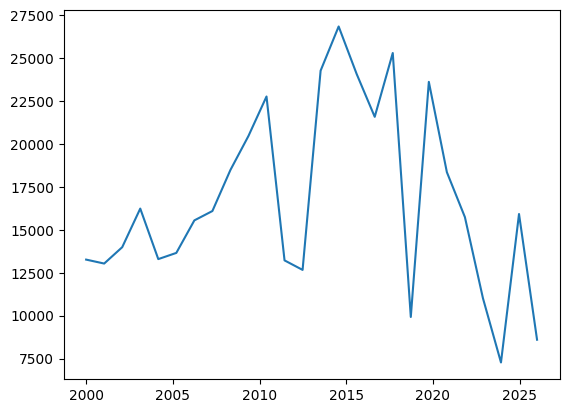

In [10]:
y=[len(annee[year]) for year in annee]
x=np.linspace(2000,2026,26)
plt.plot(x,y)
plt.show()

In [12]:
annee.keys()

dict_keys([2007, 2009, 2008, 2005, 2006, 2003, 2004, 2002, 2000, 2001, 2016, 2017, 2010, 2024, 2013, 2014, 2012, 2015, 2025, 2023, 2022, 2021, 2020, 2019, 2011, 2018])

In [4]:
pandas={}
for i in tqdm(annee):
    for j in annee[i]:
        if not j in pandas:
            pandas[j]=[0 for _ in range(26)]
            
        pandas[j][2000-i]=annee[i][j]

100%|██████████| 26/26 [00:00<00:00, 38.28it/s]


In [5]:
df=pd.DataFrame.from_dict(pandas,orient='index',columns=[2000+i for i in range(26)])

In [6]:
df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
monsieur,224,139,895,983,458,629,387,111,117,242,...,165,148,125,127,137,265,216,147,133,205
président,327,204,985,1018,688,627,433,118,229,273,...,295,335,327,306,174,284,272,240,191,316
ministre,260,438,2855,2323,1064,935,457,264,515,185,...,164,108,130,149,115,266,219,203,187,321
chers,41,17,103,99,55,37,37,15,47,40,...,26,27,28,53,48,62,40,60,48,46
collègues,50,24,198,175,89,89,66,15,57,34,...,18,21,11,18,14,25,18,27,11,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
remote,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
frenchbee,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
norwegian,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
basage,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.drop(columns=[2025],inplace=True)

In [7]:
del annee,discours,pandas

In [8]:
for i in df.columns:
    a=df[i].nlargest(5)
    print(i,list(a.keys()))

2000 ['européenne', 'europe', 'faire', 'pays', 'union']
2001 ['ministre', 'france', 'gouvernement', 'président', 'faire']
2002 ['ministre', 'france', 'euros', 'état', 'faire']
2003 ['ministre', 'france', 'euros', 'faire', 'bien']
2004 ['ministre', 'france', 'faire', 'gouvernement', 'président']
2005 ['état', 'ministre', 'euros', 'crise', 'territoires']
2006 ['état', 'santé', 'ministre', 'président', 'secrétaire']
2007 ['ministre', 'état', 'projet', 'publique', 'gouvernement']
2008 ['ministre', 'projet', 'état', 'bien', 'président']
2009 ['france', 'faire', 'faut', "aujourd'hui", 'bien']
2010 ['france', 'pays', 'faire', 'faut', 'bien']
2011 ['france', 'pays', 'faut', 'faire', 'bien']
2012 ['france', 'pays', 'faire', 'faut', 'bien']
2013 ['france', 'pays', 'bien', 'faire', 'faut']
2014 ['france', 'c\x92est', 'pays', 'faire', 'bien']
2015 ['france', 'c\x92est', 'bien', 'faire', 'pays']
2016 ['france', 'europe', 'pays', 'faire', 'bien']
2017 ['faire', 'bien', 'pays', 'france', "aujourd'hui

In [11]:
for i in df.columns:
    a=df[i].nsmallest(5)
    print(i,list(a.keys()))

2000 ['éculées', 'cocasse', 'plfr', 'reportez', 'reculs']
2001 ['rectificative', 'marquent', 'éculées', 'avouez', 'cocasse']
2002 ['éculées', 'avouez', 'cocasse', 'apparaîtra', 'reportez']
2003 ['éculées', 'cocasse', 'apparaîtra', 'reportez', 'dépeçage']
2004 ['éculées', 'avouez', 'cocasse', 'apparaîtra', 'reculs']
2005 ['éculées', 'cocasse', 'inflationniste', 'reculs', 'dépeçage']
2006 ['éculées', 'avouez', 'cocasse', 'apparaîtra', 'reportez']
2007 ['marquent', 'éculées', 'proposez', 'avouez', 'cocasse']
2008 ['éculées', 'avouez', 'cocasse', 'apparaîtra', 'plfr']
2009 ['marquent', 'éculées', 'avouez', 'cocasse', 'finance']
2010 ['éculées', 'avouez', 'cocasse', 'apparaîtra', 'reportez']
2011 ['éculées', 'cocasse', 'reportez', 'dépeçage', 'titrait']
2012 ['éculées', 'avouez', 'apparaîtra', 'reportez', 'inflationniste']
2013 ['éculées', 'avouez', 'cocasse', 'plfr', 'reportez']
2014 ['éculées', 'avouez', 'cocasse', 'reportez', 'inflationniste']
2015 ['rectificative', 'éculées', 'avouez', 

dropping unused words

In [28]:
a=df.sum(axis=1)
df=df[a>=10]

In [34]:
df.shape

(21391, 25)

In [33]:
df_norm=StandardScaler().fit_transform(df)

In [49]:
forest=IsolationForest().fit_predict(df_norm)

In [50]:
forest

array([-1, -1, -1, ...,  1,  1,  1])

In [51]:
np.sum([1 if i==-1 else 0 for i in forest])

1628

In [52]:
df['forest']=forest

C:\Users\math\AppData\Local\Temp\ipykernel_17084\2002171592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['forest']=forest


In [55]:
df[df['forest']==1]

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,cluster,forest
rectificative,5,0,10,14,14,51,26,4,1,1,...,6,0,7,1,2,7,1,0,0,1
discuté,14,3,7,8,8,9,1,2,6,6,...,6,8,6,2,1,10,2,3,0,1
marquent,6,0,2,3,3,4,1,0,1,0,...,0,1,2,5,2,2,2,3,0,1
défiance,3,3,7,15,5,9,3,2,1,6,...,4,8,2,0,2,2,1,4,0,1
accrue,23,5,8,14,10,7,3,2,1,4,...,2,6,15,9,17,9,7,13,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
notre-dame-des-landes,0,0,0,0,0,0,0,8,4,0,...,0,0,0,0,0,0,0,0,0,1
\n \n,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
grignon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
strmtg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [35]:
kmeans = KMeans(n_clusters=5, random_state=42).fit_predict(df_norm)

In [36]:
df['cluster']=kmeans

C:\Users\math\AppData\Local\Temp\ipykernel_17084\3645791761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster']=kmeans


In [37]:
df['cluster'].value_counts()

cluster
0    19535
4     1380
3      359
1      103
2       14
Name: count, dtype: int64

In [48]:
from sklearn.cluster import DBSCAN
clustering = DBSCAN().fit_predict(df_norm)
print(np.count_nonzero(clustering==0))
print(np.count_nonzero(clustering==-1))

16239
5152


In [26]:
df[df['forest']==-1]['cluster'].value_counts()

cluster
0    4855
3    1061
1     165
4      25
2       1
Name: count, dtype: int64

In [27]:
df[df['forest']==1]['cluster'].value_counts()

cluster
0    76337
Name: count, dtype: int64

In [56]:
df.describe()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,cluster,forest
count,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,...,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000,21391.000000
mean,8.253752,2.163293,14.057407,14.223692,7.732364,7.107896,3.525268,1.662101,2.338834,4.226778,...,3.728998,4.531953,4.006919,4.357767,6.734982,6.570006,4.554252,5.624375,0.314525,0.847786
std,31.584412,8.896308,54.839910,54.289299,29.059560,30.726839,15.369070,7.179830,10.417144,15.663262,...,13.882463,17.583738,15.116563,16.674665,25.016730,24.302553,18.433973,20.496177,1.044898,0.530350
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,0.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,5.000000,1.000000,8.000000,8.000000,5.000000,4.000000,2.000000,1.000000,1.000000,2.000000,...,2.000000,3.000000,2.000000,2.000000,4.000000,4.000000,3.000000,3.000000,0.000000,1.000000
max,903.000000,438.000000,2855.000000,2323.000000,1064.000000,1208.000000,673.000000,264.000000,515.000000,586.000000,...,387.000000,601.000000,456.000000,551.000000,631.000000,619.000000,752.000000,610.000000,4.000000,1.000000


<Axes: title={'center': 'Average usage per year'}>

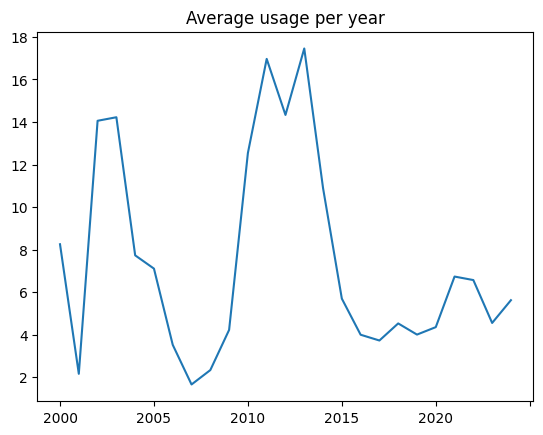

In [59]:
df.drop(columns=['cluster','forest']).mean(axis=0).plot(title="Average usage per year")

In [61]:
df_new=df.drop(columns=['cluster','forest'])

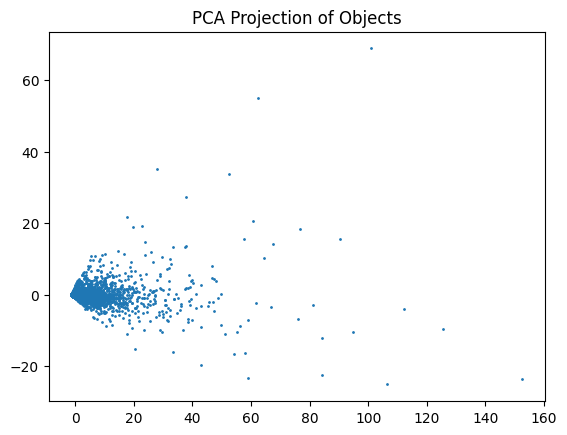

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(df_norm)

# Plot the 2D projection
import matplotlib.pyplot as plt
plt.scatter(X_pca[:,0], X_pca[:,1], s=1)
plt.title("PCA Projection of Objects")
plt.show()


In [67]:
pca.explained_variance_ratio_

array([0.79292605, 0.05744747, 0.02708128, 0.01637806, 0.01464691,
       0.01255872, 0.01017861, 0.00868517, 0.00841404, 0.00694002])

In [72]:
norm_df=pd.DataFrame(columns=[i for i in range(2000,2025)],data=df_norm)

In [82]:
norm_df.index=df.index

In [83]:
norm_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
monsieur,6.830942,15.381651,16.064271,17.845118,15.495010,20.239851,24.951652,15.228836,11.007225,15.180668,...,10.995095,10.160882,10.392564,6.851266,8.136503,7.954902,10.323933,8.617814,7.727530,6.214749
président,10.092121,22.688223,17.705450,18.489828,23.409974,20.174760,27.944746,16.203812,21.758984,17.159868,...,17.875502,18.365345,23.863111,18.339422,19.978096,10.173889,11.083443,10.922153,12.772681,9.044612
ministre,7.970772,48.991883,51.805501,42.528276,36.349220,30.198804,29.506360,36.539030,49.214369,11.541494,...,9.309167,10.097771,7.511163,7.135626,9.591894,6.635505,10.363908,8.741261,10.765470,8.849449
chers,1.036809,1.667776,1.621897,1.561602,1.626616,0.972856,2.178109,1.857733,4.287376,2.283947,...,0.423872,1.388418,1.676327,1.334676,3.241096,2.617339,2.209174,1.375608,3.007873,2.067538
collègues,1.321767,2.454638,3.354252,2.961543,2.796654,2.665228,4.065060,1.857733,5.247354,1.900876,...,0.332741,0.883528,1.244117,0.367851,0.925700,0.578270,0.730129,0.470332,1.217658,0.262281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
notre-dame-des-landes,-0.261330,-0.243173,-0.256341,-0.262004,-0.266093,-0.231331,-0.229380,0.882757,0.159468,-0.269859,...,-0.259612,-0.252475,-0.268618,-0.257741,-0.265074,-0.261347,-0.269225,-0.270349,-0.247063,-0.274417
\n \n,-0.261330,-0.243173,-0.256341,-0.262004,-0.266093,-0.231331,-0.229380,-0.231501,-0.224523,-0.269859,...,2.565456,-0.252475,-0.268618,-0.257741,-0.265074,-0.261347,-0.269225,-0.270349,-0.247063,-0.274417
grignon,-0.261330,-0.243173,-0.256341,-0.262004,-0.266093,-0.231331,-0.229380,-0.231501,-0.224523,-0.269859,...,0.196044,-0.252475,-0.268618,-0.257741,-0.265074,-0.261347,-0.269225,-0.270349,-0.247063,-0.274417
strmtg,-0.261330,-0.243173,-0.256341,-0.262004,-0.266093,-0.231331,-0.229380,-0.231501,-0.224523,-0.269859,...,0.241610,-0.252475,-0.268618,-0.257741,-0.265074,-0.261347,-0.269225,-0.270349,-0.247063,-0.274417


<Axes: >

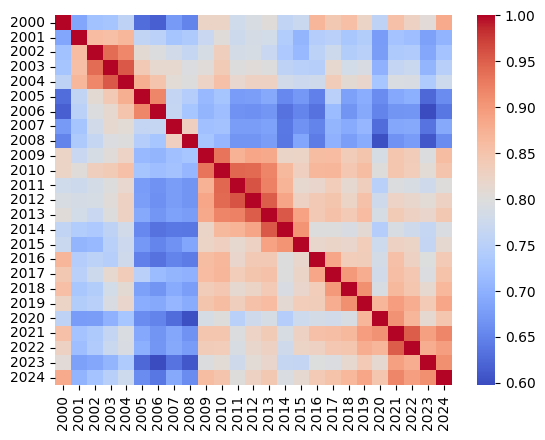

In [77]:
sns.heatmap(norm_df.corr(), cmap="coolwarm")

In [84]:
norm_df.std(axis=1).nlargest(10)

ministre    15.112450
france      12.181513
état        11.690056
cest       10.398243
pays         8.784494
femmes       8.523146
euros        7.930634
santé        7.902637
europe       7.292738
parole       7.194495
dtype: float64

In [ ]:
df[df['forest']==-1]['cluster'].value_counts()

cluster
4    1127
3     359
1     103
0      25
2      14
Name: count, dtype: int64

In [94]:
len(df[df['forest']==-1])

1628

In [87]:
df[df['forest']==1]['cluster'].value_counts()

cluster
0    19510
4      253
Name: count, dtype: int64

In [95]:
df[df.index.isin(list(norm_df.mean(axis=1).nlargest(1628).index))]['forest'].value_counts()

forest
-1    1542
 1      86
Name: count, dtype: int64

In [ ]:
norm_df['forest']=df['forest']
norm_df['cluster']=df['cluster']

In [102]:
for cluster in norm_df.groupby('cluster'):
    print(cluster[0],cluster[1]['forest'].value_counts())

0 forest
 1    19510
-1       25
Name: count, dtype: int64
1 forest
-1    103
Name: count, dtype: int64
2 forest
-1    14
Name: count, dtype: int64
3 forest
-1    359
Name: count, dtype: int64
4 forest
-1    1127
 1     253
Name: count, dtype: int64


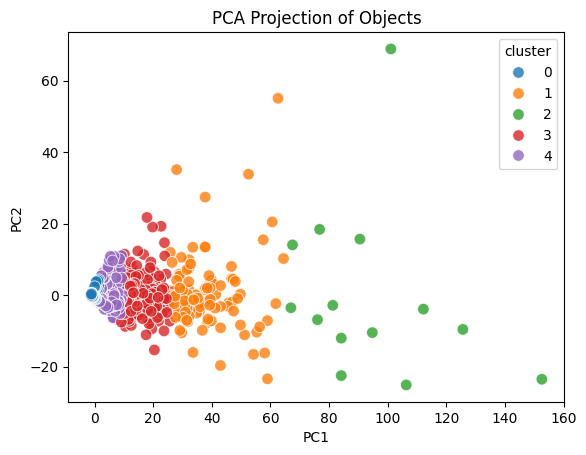

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(df_norm)
norm_df["PC1"]=X_pca[:,0]
norm_df["PC2"]=X_pca[:,1]
# Plot the 2D projection
import matplotlib.pyplot as plt
sns.scatterplot(data=norm_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70, alpha=0.8)
plt.title("PCA Projection of Objects")
plt.show()


In [117]:
norm_df[norm_df['PC1']>80]

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2020,2021,2022,2023,2024,forest,cluster,PC1,PC2,mean
président,10.092121,22.688223,17.705450,18.489828,23.409974,20.174760,27.944746,16.203812,21.758984,17.159868,...,10.173889,11.083443,10.922153,12.772681,9.044612,-1,2,90.500235,15.683150,19.346849
ministre,7.970772,48.991883,51.805501,42.528276,36.349220,30.198804,29.506360,36.539030,49.214369,11.541494,...,6.635505,10.363908,8.741261,10.765470,8.849449,-1,2,101.059333,68.851116,23.666736
pays,23.516778,15.606468,16.848390,15.910990,16.665048,8.263071,7.838961,10.771802,5.535348,21.437493,...,19.409673,17.199493,17.588275,23.351223,22.022945,-1,2,106.305272,-25.096942,20.937925
france,17.785969,29.320342,32.968414,30.886667,28.778385,12.949637,10.897123,14.253860,11.775208,37.143401,...,27.086168,24.954485,25.200822,33.061782,29.487926,-1,2,152.572999,-23.509292,30.476100
bien,22.440273,17.742235,19.328394,20.166072,21.517265,19.393666,19.486002,17.457353,21.854982,21.629029,...,15.271562,20.757196,21.579719,20.259034,18.656385,-1,2,112.156547,-3.902086,23.045051
travail,13.036680,11.559751,12.581325,16.942525,20.175163,16.659835,15.321697,11.746778,12.735186,15.627584,...,13.532356,16.839726,15.901170,21.669506,18.753966,-1,2,81.255904,-2.840064,16.710703
politique,19.938980,14.707198,13.365444,10.808576,11.606353,5.952333,5.431473,8.682567,11.103223,18.372926,...,19.049837,21.956421,19.275380,25.792425,26.560483,-1,2,84.130305,-22.487057,16.560795
aujourd'hui,17.406026,18.304279,11.888383,9.206013,10.505141,10.118170,12.003266,13.836013,14.655143,21.692874,...,20.309262,23.715285,21.003634,19.174055,21.681410,-1,2,84.144407,-12.015942,16.963415
faut,19.305742,19.990411,14.824269,17.495133,16.561809,11.094538,10.246450,11.189649,14.559145,23.225158,...,15.271562,18.718512,16.189213,18.577317,20.900758,-1,2,94.731770,-10.466970,19.149918
faire,24.466636,21.901361,22.081927,24.200110,26.438308,19.719122,18.835329,16.203812,17.727074,27.247402,...,23.307893,24.874537,23.966355,25.087189,26.560483,-1,2,125.631271,-9.568445,25.584560


In [116]:
norm_df['mean']=norm_df.mean(axis=1)
from scipy.stats import pearsonr, spearmanr

corr_pearson, _ = pearsonr(norm_df['mean'], norm_df['PC1'])
print(f"Corrélation de Pearson: {corr_pearson}")

# Calculer la corrélation de Spearman
corr_spearman, _ = spearmanr(norm_df['mean'], norm_df['PC1'])
print(f"Corrélation de Spearman: {corr_spearman}")

# Calculer la matrice de corrélation avec pandas
corr_matrix = norm_df[['mean','PC1']].corr()
print("Matrice de corrélation:")
print(corr_matrix)

Corrélation de Pearson: 0.9984102126572237
Corrélation de Spearman: 0.9961732663295432
Matrice de corrélation:
         mean      PC1
mean  1.00000  0.99841
PC1   0.99841  1.00000


In [127]:
from scipy.stats import pearsonr, spearmanr
norm_df['std']=df_norm.std(axis=1)
corr_pearson, _ = pearsonr(norm_df['std'], norm_df['PC1'])
print(f"Corrélation de Pearson: {corr_pearson}")

# Calculer la corrélation de Spearman
corr_spearman, _ = spearmanr(norm_df['std'], norm_df['PC1'])
print(f"Corrélation de Spearman: {corr_spearman}")

# Calculer la matrice de corrélation avec pandas
corr_matrix = norm_df[['std','PC1']].corr()
print("Matrice de corrélation:")
print(corr_matrix)

Corrélation de Pearson: 0.8063651584248834
Corrélation de Spearman: 0.8987622987502516
Matrice de corrélation:
          std       PC1
std  1.000000  0.806365
PC1  0.806365  1.000000


In [128]:
df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,cluster,forest
monsieur,224,139,895,983,458,629,387,111,117,242,...,148,125,127,137,265,216,147,133,1,-1
président,327,204,985,1018,688,627,433,118,229,273,...,335,327,306,174,284,272,240,191,2,-1
ministre,260,438,2855,2323,1064,935,457,264,515,185,...,108,130,149,115,266,219,203,187,2,-1
chers,41,17,103,99,55,37,37,15,47,40,...,27,28,53,48,62,40,60,48,4,-1
collègues,50,24,198,175,89,89,66,15,57,34,...,21,11,18,14,25,18,27,11,4,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
notre-dame-des-landes,0,0,0,0,0,0,0,8,4,0,...,0,0,0,0,0,0,0,0,0,1
\n \n,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
grignon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
strmtg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


TF  idf


In [129]:
norm_df['max_yearly_increase'] = norm_df.diff(axis=1).max(axis=1)
top_spikes = norm_df['max_yearly_increase'].nlargest(20)
print(top_spikes)

france          150.572999
faire           123.631271
bien            110.156547
pays            104.305272
ministre         99.059333
faut             92.731770
président        88.500235
aujourd'hui      82.144407
politique        82.130305
travail          79.255904
gouvernement     74.768130
ensemble         74.037831
question         65.503166
français         64.964850
projet           63.442311
état             61.570236
entreprises      60.810383
monsieur         59.582914
contre           57.961788
europe           57.960365
Name: max_yearly_increase, dtype: float64


In [131]:
norm_df.columns

Index([                 2000,                  2001,                  2002,
                        2003,                  2004,                  2005,
                        2006,                  2007,                  2008,
                        2009,                  2010,                  2011,
                        2012,                  2013,                  2014,
                        2015,                  2016,                  2017,
                        2018,                  2019,                  2020,
                        2021,                  2022,                  2023,
                        2024,              'forest',             'cluster',
                       'PC1',                 'PC2',                'mean',
                       'std', 'max_yearly_increase'],
      dtype='object')

In [133]:
norm_df.drop(columns=['forest','cluster','PC1','PC2','mean','std','max_yearly_increase']).diff(axis=1)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
monsieur,NaN,8.550708,0.682621,1.780847,-2.350108,4.744841,4.711801,-9.722816,-4.221611,4.173443,...,2.938927,-0.834212,0.231681,-3.541298,1.285237,-0.181601,2.369031,-1.706119,-0.890284,-1.512781
président,NaN,12.596102,-4.982773,0.784377,4.920146,-3.235214,7.769986,-11.740934,5.555172,-4.599116,...,-3.481888,0.489843,5.497766,-5.523689,1.638674,-9.804207,0.909554,-0.161290,1.850528,-3.728069
ministre,NaN,41.021111,2.813618,-9.277225,-6.179056,-6.150415,-0.692444,7.032670,12.675338,-37.672874,...,-6.207549,0.788604,-2.586608,-0.375537,2.456268,-2.956389,3.728403,-1.622647,2.024209,-1.916022
chers,NaN,0.630967,-0.045880,-0.060295,0.065014,-0.653759,1.205253,-0.320376,2.429642,-2.003429,...,-0.582419,0.964546,0.287909,-0.341651,1.906420,-0.623757,-0.408165,-0.833566,1.632265,-0.940335
collègues,NaN,1.132871,0.899614,-0.392710,-0.164888,-0.131426,1.399832,-2.207326,3.389621,-3.346478,...,-1.198298,0.550787,0.360589,-0.876266,0.557849,-0.347430,0.151859,-0.259797,0.747326,-0.955377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
notre-dame-des-landes,NaN,0.018157,-0.013168,-0.005663,-0.004089,0.034762,0.001951,1.112137,-0.723289,-0.429328,...,-0.011071,0.007137,-0.016144,0.010877,-0.007333,0.003728,-0.007879,-0.001123,0.023285,-0.027354
\n \n,NaN,0.018157,-0.013168,-0.005663,-0.004089,0.034762,0.001951,-0.002122,0.006978,-0.045336,...,2.813997,-2.817931,-0.016144,0.010877,-0.007333,0.003728,-0.007879,-0.001123,0.023285,-0.027354
grignon,NaN,0.018157,-0.013168,-0.005663,-0.004089,0.034762,0.001951,-0.002122,0.006978,-0.045336,...,0.444585,-0.448519,-0.016144,0.010877,-0.007333,0.003728,-0.007879,-0.001123,0.023285,-0.027354
strmtg,NaN,0.018157,-0.013168,-0.005663,-0.004089,0.034762,0.001951,-0.002122,0.006978,-0.045336,...,0.490151,-0.494085,-0.016144,0.010877,-0.007333,0.003728,-0.007879,-0.001123,0.023285,-0.027354


In [138]:
prev = norm_df.drop(columns=['forest','cluster','PC1','PC2','mean','std','max_yearly_increase','max_relative_increase']).iloc[:, :-1]
next_ = norm_df.drop(columns=['forest','cluster','PC1','PC2','mean','std','max_yearly_increase','max_relative_increase']).iloc[:, 1:]
epsilon = 1e-5

relative_diff = (next_.values - prev.values) / (prev.values + epsilon)
relative_diff[prev.values == 0] = np.nan  # ignore 0→N jumps

relative_diff_df = pd.DataFrame(relative_diff, index=df.index, columns=next_.columns)

norm_df['max_relative_increase'] = relative_diff_df.max(axis=1)
norm_df['year_of_max_relative_increase'] = relative_diff_df.idxmax(axis=1)


In [146]:
relative_diff_df.min(axis=1).nlargest(10)

grever           -0.108158
prospéré         -0.119286
diligence        -0.122813
acronyme         -0.122948
accroissant      -0.123900
tremblante       -0.123900
calmer           -0.130644
révélés          -0.130644
retrousser       -0.130644
correspondante   -0.130644
dtype: float64

In [145]:
norm_df[norm_df.index=='olympique']

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2024,forest,cluster,PC1,PC2,mean,std,max_yearly_increase,max_relative_increase,year_of_max_relative_increase
olympique,-0.071358,-0.130764,-0.055753,-0.151483,-0.266093,-0.231331,-0.22938,-0.231501,-0.224523,-0.206014,...,0.018327,1,0,-0.152801,-0.70029,-0.022476,0.297444,0.981673,13771.214796,2017


In [ ]:
norm_df['max_relative_increase']

In [137]:
norm_df.columns

Index([                   2000,                    2001,
                          2002,                    2003,
                          2004,                    2005,
                          2006,                    2007,
                          2008,                    2009,
                          2010,                    2011,
                          2012,                    2013,
                          2014,                    2015,
                          2016,                    2017,
                          2018,                    2019,
                          2020,                    2021,
                          2022,                    2023,
                          2024,                'forest',
                     'cluster',                   'PC1',
                         'PC2',                  'mean',
                         'std',   'max_yearly_increase',
       'max_relative_increase'],
      dtype='object')